# El Niño and sea level at *your* station

In class we built this analysis for San Diego: monthly mean sea level, detrended,
its seasonal cycle tiled over a 24-month window, and the big El Niño winters drawn
on top. Now your group owns one station and carries it through three notebooks —
sea level (this one), waves (12), and total water level (13). At the end, every
group puts its numbers on the board and we assemble the alongshore story together:
where the El Niño pulse lands relative to each station's seasonal cycle, and why
the answer changes with latitude.

The notebook runs end-to-end as-is — for San Diego, the demo you just watched.
Your first move is claiming your station; the **TODO** markers are the parts you
change or complete. The full instructor version with all ten stations is in
`reference/11_el_nino_sea_level_complete.ipynb`; try things here first.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Everything in the course runs relative to the project root, never to a
# personal path, so the same notebook works on every machine.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

# Raw provider files live here, exactly as downloaded (course data contract).
UHSLC_RAW = PROJECT_ROOT / "data" / "raw" / "uhslc"
UHSLC_RAW.mkdir(parents=True, exist_ok=True)

## 1. Claim your station

Daily tide gauge records come from the
[University of Hawaii Sea Level Center](https://uhslc.soest.hawaii.edu/data/) —
find your station on their map and confirm the file name below matches what they
serve. Active stations live in the fast-delivery archive; stations whose feed ended
live in the research-quality archive with a letter in the filename (the helper
tries both). South Beach and Astoria are sea-level-only sites: MOP wave transects
stop at the Oregon border, so those groups partner with a California group for
notebooks 12 and 13.

In [2]:
STATIONS = {
    # name: UHSLC daily file        record ends   notes
    "San Diego":     "d569.nc",   # 2026 —— the in-class demo
    "La Jolla":      "d554.nc",   # 2026
    "Los Angeles":   "d567a.nc",  # 2021
    "Port San Luis": "d565a.nc",  # 2021
    "Monterey":      "d555a.nc",  # 2021
    "San Francisco": "d551.nc",   # 2026
    "Humboldt Bay":  "d576a.nc",  # 2021
    "Crescent City": "d556.nc",   # 2026
    "South Beach":   "d592.nc",   # 2026 —— Oregon: sea level only
    "Astoria":       "d572a.nc",  # 2024 —— Oregon: sea level only
}

MY_SITE = "San Diego"  # TODO: change to your group's station

UHSLC_BASE = "https://uhslc.soest.hawaii.edu/data/netcdf"
# Two archives: "fast" holds stations that still report; "rqds" (research
# quality) holds finished records. We try fast first, then fall back.
ARCHIVES = ["fast/daily", "rqds/pacific/daily"]


def fetch_station(filename):
    """Download one UHSLC daily NetCDF file into data/raw/uhslc, if not there."""
    target = UHSLC_RAW / filename
    if target.exists():
        return target  # already on disk: never re-download raw data
    for archive in ARCHIVES:
        try:
            urlretrieve(f"{UHSLC_BASE}/{archive}/{filename}", target)
            print(f"downloaded {filename} from {archive}")
            return target
        except HTTPError:
            continue  # not in this archive; try the next one
    raise FileNotFoundError(f"{filename} not found in any UHSLC archive")


path = fetch_station(STATIONS[MY_SITE])
print(MY_SITE, "->", path)

San Diego -> /Users/holden/Documents/Scripps/Teaching/Climate_science_bootcamp/data/raw/uhslc/d569.nc


## 2. Look at the whole record before averaging anything

The file holds daily `sea_level` in millimeters on the station datum. We work in
centimeters.

**TODO (markdown):** after running the cell, record two things about your station:
when does the record start, and can you spot the century-scale drift in the cloud?
That drift is relative sea level rise, and it is comparable in size to the signals
we want to compare — which is why the next section removes it.

San Diego (32.71°N): 1906-01-22 to 2026-06-30, 905 missing days


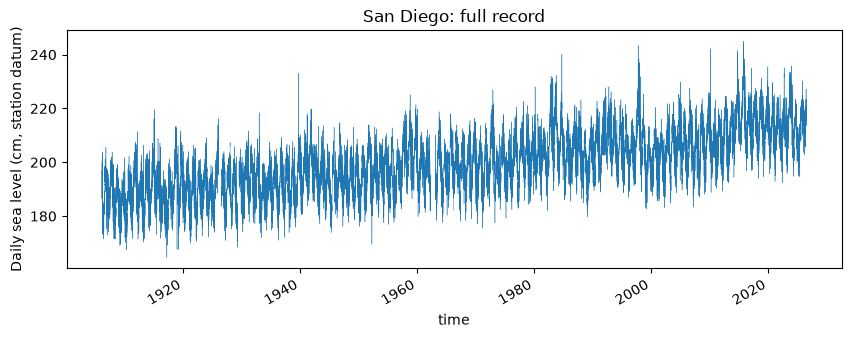

In [3]:
def load_daily(path):
    """Daily sea level as a pandas Series in cm, plus station name and latitude."""
    with xr.open_dataset(path) as ds:
        name = ds["station_name"].values.astype(str).item()
        lat = float(ds["lat"].values.squeeze())
        # sea_level has a length-1 "record_id" dimension we don't need; squeeze
        # it away, turn the rest into a pandas time series, and convert mm -> cm.
        daily = ds["sea_level"].squeeze("record_id", drop=True).to_series() * 0.1
    return daily, name, lat


daily, name, lat = load_daily(path)
print(f"{name} ({lat:.2f}°N): {daily.index[0].date()} to {daily.index[-1].date()}, "
      f"{daily.isna().sum()} missing days")

fig, ax = plt.subplots(figsize=(10, 3.5))
daily.plot(ax=ax, lw=0.3)  # thin line: ~40,000 daily points
ax.set_ylabel("Daily sea level (cm, station datum)")
ax.set_title(f"{name}: full record")
plt.show()

## 3. Monthly means, smoothed, detrended

Three steps, in order (this is the same processing chain as Prof. Merrifield's
MATLAB code): calendar-month means (months with fewer than 15 valid days become
NaN), a 3-month running mean, and removal of the linear trend, which takes out sea
level rise and vertical land motion and centers the series on zero.

**TODO (markdown):** compare your printed trend against NOAA's published value for
your station (search "NOAA tides and currents sea level trends" + your station).
If they disagree wildly, stop and debug. If your trend is unusually large or small
compared to neighboring stations, what — besides the ocean — could be moving?

In [4]:
def monthly_means(daily):
    """Calendar-month means; poorly sampled months become NaN."""
    grouped = daily.resample("MS")   # "MS" = group by month, stamp at month start
    monthly = grouped.mean()         # mean of the available days in each month
    # a month with fewer than 15 real observations is not a trustworthy average
    monthly[grouped.count() < 15] = np.nan
    return monthly


def smooth_3month(monthly):
    """Centered 3-month running mean, tolerant of one missing neighbor."""
    return monthly.rolling(3, center=True, min_periods=2).mean()


def remove_trend(monthly):
    """Subtract the least-squares line. Returns (detrended cm, trend mm/yr)."""
    # time axis in fractional years, stamped at each month's center
    years = monthly.index.year + (monthly.index.month - 0.5) / 12
    valid = monthly.notna()          # polyfit cannot handle NaN months
    slope, intercept = np.polyfit(years[valid], monthly[valid], 1)
    # subtract the fitted line everywhere; slope is cm/yr, x10 gives mm/yr
    return monthly - (slope * years + intercept), slope * 10


sl, trend = remove_trend(smooth_3month(monthly_means(daily)))
print(f"{name} linear trend: {trend:.1f} mm/yr")

San Diego linear trend: 2.2 mm/yr


## 4. The two-year window and the El Niño events

An El Niño event peaks in the winter that straddles a year boundary, so we plot a
24-month axis — January of the onset year through December of the following year —
with the seasonal climatology tiled twice for reference.

**TODO (code):** the `EVENTS` list below only has the two oldest events. Add
**2015–16**, **2023–24**, and the current **2026–27** event, choosing a line style
for each that keeps every curve identifiable in black-and-white print (the current
event is traditionally red). Style dicts take matplotlib `color`, `ls`, `lw`.

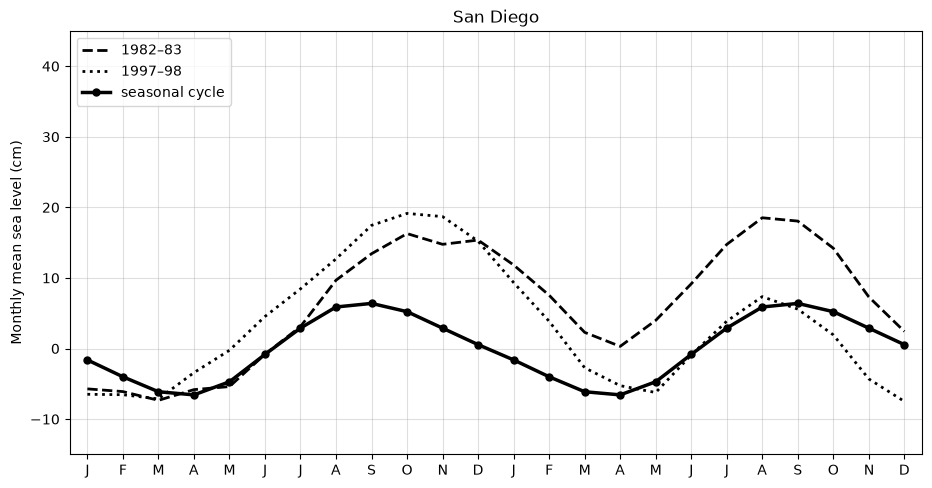

seasonal range 13.0 cm, max month 9, min month 4
1982–83: peak departure +14.8 cm in 1982-12
1997–98: peak departure +15.8 cm in 1997-11


In [5]:
EVENTS = [
    # (onset year, legend label, line style)
    (1982, "1982–83", dict(color="k", ls="--", lw=2)),
    (1997, "1997–98", dict(color="k", ls=":", lw=2)),
    # TODO: add (2015, "2015–16", ...), (2023, "2023–24", ...),
    #       and (2026, "2026–27", ...) with your own line styles
]


def seasonal_climatology(sl):
    """Mean of the detrended series for each calendar month. 12 values."""
    return sl.groupby(sl.index.month).mean()


def two_year_window(sl, onset_year):
    """The 24 monthly values from Jan(onset_year) through Dec(onset_year+1)."""
    # build the 24 month-start dates we want, then ask the series for exactly
    # those; months outside the record come back as NaN (nothing to plot)
    idx = pd.date_range(f"{onset_year}-01-01", periods=24, freq="MS")
    return sl.reindex(idx).to_numpy()


def plot_two_year_cycle(ax, sl, title):
    months = np.arange(1, 25)        # x-axis: window month 1..24
    clim = seasonal_climatology(sl)
    for onset, label, style in EVENTS:
        window = two_year_window(sl, onset)
        if np.isnan(window).all():
            continue                 # record ends before this event: skip it
        ax.plot(months, window, label=label, **style)
    # the 12-month climatology drawn twice, so both winters have a reference
    ax.plot(months, np.tile(clim.to_numpy(), 2), "k-o", lw=2.5, ms=5,
            markerfacecolor="k", label="seasonal cycle", zorder=2)
    ax.set_xticks(months)
    ax.set_xticklabels(list("JFMAMJJASOND") * 2)   # month initials, twice over
    ax.set_xlim(0.5, 24.5)
    ax.set_ylim(-15, 45)             # one shared scale for every station
    ax.set_title(title)
    ax.grid(alpha=0.4)


fig, ax = plt.subplots(figsize=(11, 5.5))
plot_two_year_cycle(ax, sl, name)
ax.set_ylabel("Monthly mean sea level (cm)")
ax.legend(loc="upper left")
plt.show()

# numbers for the board: seasonal cycle first, then each event's peak
clim = seasonal_climatology(sl)
print(f"seasonal range {clim.max() - clim.min():.1f} cm, "
      f"max month {clim.idxmax()}, min month {clim.idxmin()}")
for onset, label, _ in EVENTS:
    # departure = event curve minus the climatology, month by month
    excess = two_year_window(sl, onset) - np.tile(clim.to_numpy(), 2)
    if np.isnan(excess).all():
        continue
    i = int(np.nanargmax(excess))    # position of the biggest departure
    print(f"{label}: peak departure {np.nanmax(excess):+.1f} cm "
          f"in {onset + i // 12}-{i % 12 + 1:02d}")

## 5. Interpret

**TODO (markdown):** answer for your station —

1. Which month is the seasonal maximum, and what physics sets it here? (South of
   the transition: summer steric heating. North: winter storms and pressure.)
2. Do the El Niño winters land on the seasonal maximum, or miss it?
3. Which event produced the biggest departure at your station? Are the events
   similar to each other, or individuals?
4. Where does the red 2026–27 curve sit compared to past events at this point in
   the calendar? If your record ends in 2021 or 2024 you cannot answer yet —
   section 6 fixes that.

## 6. Extend your station to the present with NOAA CO-OPS

UHSLC files lag the present by weeks (fast delivery) or years (research quality),
but NOAA still runs every one of these gauges, so the current event is knowable at
every station — this section appends NOAA's verified monthly means plus a
provisional current-month estimate. Datums can differ between sources, so the code
aligns them with a median offset over the shared months and prints the residual
scatter: if that scatter exceeded a centimeter or two, the station pairing would
be wrong.

**TODO (markdown):** report your offset and scatter, and note that your final
month is provisional (a partial month of preliminary data). Then answer question
4 from section 5 properly.

offset -0.0 cm over 114 shared months, scatter 0.1 cm


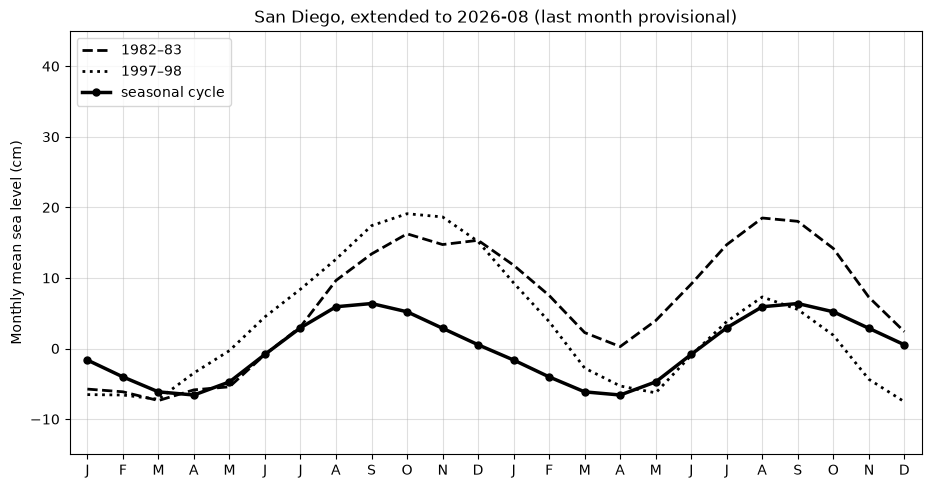

2026–27 so far: +6.3 cm above climatology in 2026-08 (provisional)


In [6]:
import json
from urllib.request import urlopen

# NOAA CO-OPS station IDs for the same gauges
COOPS_IDS = {
    "San Diego": "9410170", "La Jolla": "9410230", "Los Angeles": "9410660",
    "Port San Luis": "9412110", "Monterey": "9413450", "San Francisco": "9414290",
    "Humboldt Bay": "9418767", "Crescent City": "9419750",
    "South Beach": "9435380", "Astoria": "9439040",
}
COOPS_API = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
TODAY = pd.Timestamp.today()


def coops_request(station_id, product, begin, end):
    """One call to the NOAA CO-OPS data API, returning the rows as a list."""
    url = (f"{COOPS_API}?product={product}&begin_date={begin}&end_date={end}"
           f"&datum=STND&station={station_id}&time_zone=GMT&units=metric&format=json")
    with urlopen(url, timeout=60) as response:
        return json.load(response).get("data", [])


def extend_with_coops(monthly, station_id):
    """Append offset-adjusted CO-OPS months after the UHSLC record ends."""
    # 1) verified monthly means since 2017 (meters on NOAA's datum -> cm)
    rows = coops_request(station_id, "monthly_mean", "20170101",
                         TODAY.strftime("%Y%m%d"))
    idx = pd.to_datetime([f"{r['year']}-{int(r['month']):02d}-01" for r in rows])
    coops = pd.Series([float(r["MSL"]) * 100 for r in rows], index=idx)

    # 2) the current month so far, from the preliminary 6-minute feed
    recent = coops_request(station_id, "water_level",
                           TODAY.strftime("%Y%m01"), TODAY.strftime("%Y%m%d"))
    values = [float(r["v"]) for r in recent if r.get("v")]
    if len(values) >= 7 * 240:  # only if we have at least a week of data
        coops[pd.Timestamp(TODAY.strftime("%Y-%m-01"))] = np.mean(values) * 100

    # 3) align the two sources: the datum difference is a constant, so the
    #    median difference over shared months estimates it robustly
    both = pd.concat([monthly, coops], axis=1, keys=["uhslc", "coops"]).dropna()
    offset = (both["uhslc"] - both["coops"]).median()
    print(f"offset {offset:+.1f} cm over {len(both)} shared months, "
          f"scatter {(both['uhslc'] - both['coops'] - offset).std():.1f} cm")

    # 4) keep UHSLC as-is and append only the months it doesn't have
    tail = coops[coops.index > monthly.last_valid_index()] + offset
    return pd.concat([monthly[: monthly.last_valid_index()], tail])


extended = extend_with_coops(monthly_means(daily), COOPS_IDS[MY_SITE])
sl_ext, _ = remove_trend(smooth_3month(extended))

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_two_year_cycle(ax, sl_ext, f"{name}, extended to {extended.index[-1]:%Y-%m} "
                                "(last month provisional)")
ax.set_ylabel("Monthly mean sea level (cm)")
ax.legend(loc="upper left")
plt.show()

# the board number: where the current event sits right now, vs climatology
clim_ext = seasonal_climatology(sl_ext)
excess = two_year_window(sl_ext, 2026) - np.tile(clim_ext.to_numpy(), 2)
valid = np.where(~np.isnan(excess))[0]
if len(valid):
    i = valid[-1]                    # the latest month with data
    print(f"2026–27 so far: {excess[i]:+.1f} cm above climatology "
          f"in 2026-{i % 12 + 1:02d} (provisional)")

## 7. Bring numbers to the board

**For the class board:** station and latitude, seasonal max month, seasonal range
(cm), trend (mm/yr), peak departure (cm) for each event, and the 2026–27 latest
month from section 6. Before we compare: write your group's one-sentence
prediction of what the station one slot north of yours will show.

## Data notes

UHSLC daily tide gauge data (Caldwell, Merrifield, and Thompson 2015,
doi:10.7289/V5V40S7W) plus NOAA CO-OPS for the recent tail; raw files stay in
`data/raw/` and out of Git. Full provenance and the all-station analysis:
`reference/11_el_nino_sea_level_complete.ipynb`.